# Session 4 &mdash; ML Foundations II: Decision Trees, Evaluation Metrics, Calibration
**Data Science Techniques and Real-World Applications &mdash; WS 2026**

**Zahra Sharafi**

**Frankfurt School of Finance and Management**

Thursday 1 October 2026 

Last block, AAPL's up/down classifier had 55.0% accuracy against a 54.6% baseline &mdash; a hint
that accuracy alone doesn't tell you much. This block makes that precise: a second kind of
classifier (decision trees), then a proper look at what accuracy hides &mdash; plus a pointer to
calibration (whether a model's predicted probabilities can be trusted) for further study.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay,
)

df = pd.read_excel("data/techstocks.xlsx", sheet_name="main")
df = df.rename(columns={"Return on the S&P 500 Index": "MktReturn"})
df.head()

,PERMNO,Names Date,Ticker Symbol,Company Name,Price or Bid/Ask Average,Returns,MktReturn
0,14542,2018-01-02,GOOG,ALPHABET INC,1065.000000,0.017775,0.008303
1,14542,2018-01-03,GOOG,ALPHABET INC,1082.479980,0.016413,0.006399
2,14542,2018-01-04,GOOG,ALPHABET INC,1086.400024,0.003621,0.004029
3,14542,2018-01-05,GOOG,ALPHABET INC,1102.229980,0.014571,0.007034
4,14542,2018-01-08,GOOG,ALPHABET INC,1106.939941,0.004273,0.001662


## <span style="color:#1e3a8a">Decision trees</span>

A decision tree classifies by asking a sequence of yes/no questions about the features, splitting
the data into purer and purer groups, until it reaches a decision. **Recursive partitioning** is the
process of building it top-down:
1. Start with the entire dataset at the root.
2. Pick the feature (and split point) that best separates the classes.
3. Create a child node for each side of the split.
4. Repeat on each child, until a stopping rule is reached &mdash; independently re-picking whichever
   feature (and threshold) best separates *that* child's data. Nothing is excluded: the same feature
   can be reused again deeper in the tree, just with a different threshold (e.g. "petal length < 2"
   at the root, then "petal length < 4" in a child).

Two words worth pinning down before anything else:
- A **point** is one row of data, one example (e.g. one of AAPL's 756 days).
- A **node** is a bucket of points at some stage of the tree. The **root** node holds *all* the
  points; every split divides one node's points into two smaller **child** nodes; a node where
  splitting stops is a **leaf**.

"Best split" is usually measured by **entropy** (impurity/disorder in a node's class labels) or
**Gini impurity** (the chance of misclassifying a random point if you labeled it randomly according
to the node's class mix). Both hit their minimum (0) when a node is pure &mdash; every point in it
belongs to one class.

### Controlling how big a tree grows

Left alone, a tree keeps splitting until every leaf is pure &mdash; which usually means it has
memorized the training data, including its noise. **`max_depth`** is the most common way to stop it
early: how many levels of splits the tree is allowed to make from the root. Depth 1 = one split, two
leaves; depth 3 = up to 8 leaves. It directly trades off two failure modes:
- **Too shallow (underfitting)**: too simple to capture the real pattern.
- **Too deep (overfitting)**: fits individual training points exactly, including noise, and will
  likely do worse on new data than a moderate depth would.

There's no formula for the "right" depth &mdash; you try several values and see which does best on
data the tree didn't train on (exactly what Exercise 1, below, has you do). Other common stopping
rules work alongside `max_depth`:
- **Minimum samples per leaf** &mdash; don't split further if a node would end up too small.
- **Minimum impurity decrease** &mdash; don't bother splitting if it barely helps.
- **Pure node** &mdash; stop automatically once a node contains only one class.

### Intuition first: what entropy actually measures

Entropy asks: *if I picked one random point from this node, how surprised would I be by its class?*
- A **pure** node (everyone belongs to one class) &mdash; no surprise at all, you already know the
  answer. Entropy = 0.
- A **50/50** node (two classes, evenly split) &mdash; maximum surprise, a coin flip. Entropy is at
  its highest.

A good split is one that turns a "surprising" (high-entropy) node into two much less surprising
(lower-entropy) children &mdash; that reduction is called **information gain**, and it's exactly
what the tree searches for at every node. Formally, entropy of a node with class shares
$p_1, \dots, p_k$ is $H = -\sum_i p_i \log_2 p_i$. Entropy uses base 2 because information is measured in bits (yes/no questions).

### The full process: how a tree picks *which* feature to split on

A classic toy example makes this concrete: predicting whether tennis gets played, from the day's
weather. 8 days, 2 candidate features (`Outlook`, `Windy`), one target (`PlayTennis`):

| Outlook | Windy | PlayTennis |
|---|---|---|
| Sunny | No  | Yes |
| Sunny | Yes | No  |
| Rainy | No  | Yes |
| Rainy | No  | Yes |
| Rainy | Yes | No  |
| Sunny | No  | Yes |
| Rainy | No  | Yes |
| Sunny | Yes | No  |

5 days played, 3 didn't. At the root, the tree tries splitting on *each* candidate feature and picks
whichever gives the highest information gain.

In [2]:
def entropy(class_counts):
    counts = np.array(class_counts, dtype=float)
    p = counts / counts.sum()
    p = p[p > 0]                      # needed because log2(0) is undefined; 0 * log(0) is defined as 0
    return -np.sum(p * np.log2(p))

root_entropy = entropy([5, 3])   # 5 played, 3 didn't

# split on Outlook: Sunny = {Yes,No,Yes,No} -> 2/2 ; Rainy = {Yes,Yes,No,Yes} -> 3/1
outlook_weighted = 4/8 * entropy([2, 2]) + 4/8 * entropy([3, 1])
ig_outlook = root_entropy - outlook_weighted

# split on Windy: Windy=Yes = {No,No,No} -> 0/3 ; Windy=No = {Yes,Yes,Yes,Yes,Yes} -> 5/0
windy_weighted = 3/8 * entropy([0, 3]) + 5/8 * entropy([5, 0])
ig_windy = root_entropy - windy_weighted

print(f"root entropy:              {root_entropy:.3f}")
print(f"split on Outlook -> IG:    {ig_outlook:.3f}")
print(f"split on Windy   -> IG:    {ig_windy:.3f}")

root entropy:              0.954
split on Outlook -> IG:    0.049
split on Windy   -> IG:    0.954


`Windy` wins decisively: splitting on it produces two **perfectly pure** children (windy days
never play, calm days always do), capturing the entire 0.954 bits of root entropy as information
gain. `Outlook` only reduces entropy a little (0.049) &mdash; both Sunny and Rainy days are still a
mix of played/didn't-play. So the tree splits on `Windy` first. If either child weren't already
pure, the exact same process (try every remaining feature, measure information gain, pick the
winner) would repeat inside it &mdash; that repetition, all the way down, *is* recursive
partitioning. Here, both children come out pure after one split, so the tree is already done.

**Why *weighted*?** A split creates two children, each with its own entropy &mdash; but they don't
usually get the same number of points. A child with only 1 point can look perfectly pure (entropy 0)
just by luck, while the other child, holding the other 7 points, might still be a mess. If we
averaged the two entropies equally, that lucky 1-point child would count just as much as the
7-point one. Weighting by each child's *share of the points* (e.g. 4/8 and 4/8, or 3/8 and 5/8)
fixes that: a child holding more of the data has proportionally more say in how good the split
really is.

Let sklearn actually build this tree and draw it, so "node" stops being an abstract word:

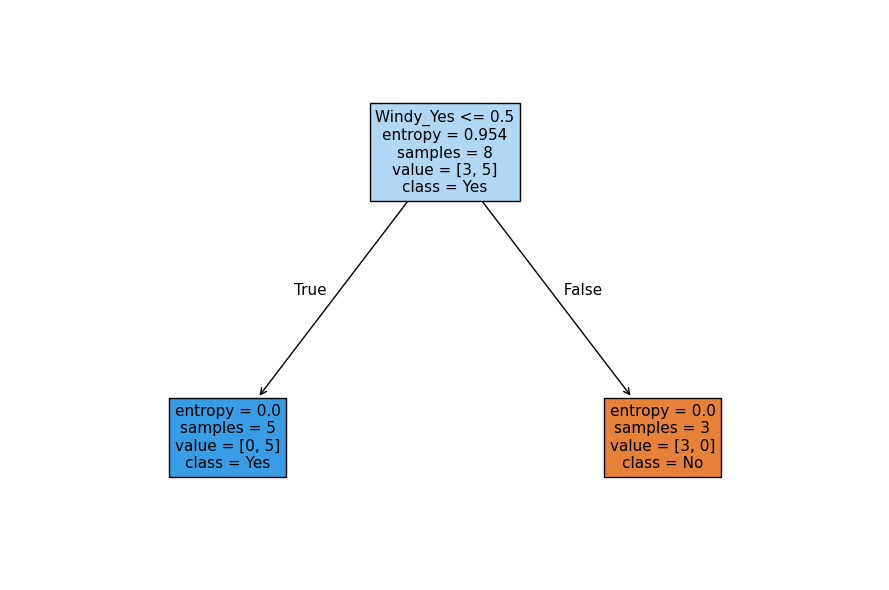

In [3]:
tennis = pd.DataFrame({
    "Outlook":     ["Sunny", "Sunny", "Rainy", "Rainy", "Rainy", "Sunny", "Rainy", "Sunny"],
    "Windy":       ["No",    "Yes",   "No",    "No",    "Yes",   "No",    "No",    "Yes"],
    "PlayTennis":  ["Yes",   "No",    "Yes",   "Yes",   "No",    "Yes",   "Yes",   "No"],
})
X_tennis = pd.get_dummies(tennis[["Outlook", "Windy"]], drop_first=True)   # -> Outlook_Sunny, Windy_Yes
y_tennis = tennis["PlayTennis"]

tennis_tree = DecisionTreeClassifier(criterion="entropy", random_state=42).fit(X_tennis, y_tennis)

fig, ax = plt.subplots(figsize=(9, 6))
plot_tree(tennis_tree, feature_names=X_tennis.columns, class_names=tennis_tree.classes_,
          filled=True, ax=ax, fontsize=11)
plt.tight_layout()
plt.show()

The **root node** (top box) holds all 8 points: `entropy = 0.954`, `value = [3, 5]` (3 No, 5 Yes)
&mdash; exactly what we computed by hand. It splits on `Windy_Yes <= 0.5` (i.e. Windy = No), exactly
the feature we picked by information gain. Each **leaf** (bottom boxes) holds the points that ended
up there: 5 points, all "Yes", entropy 0; 3 points, all "No", entropy 0. Every number in every box is
just "how many points landed in this node, and how mixed are their classes" &mdash; nothing more.

### Fitting a real tree: decision boundaries on the iris data

We switch datasets for a moment: `iris` (3 flower species, 2 features here) gives a clean 2D picture
of what a tree's decision regions actually look like &mdash; something our finance data, with only
one or two weakly-informative continuous predictors, wouldn't show as clearly.

In [4]:
iris = load_iris()
print("feature names:", iris.feature_names)
print("target (species) names:", iris.target_names)
print("data shape:", iris.data.shape, "  (150 flowers, 4 measurements each)")

pd.DataFrame(iris.data, columns=iris.feature_names).assign(species=iris.target).head()

feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
target (species) names: ['setosa' 'versicolor' 'virginica']
data shape: (150, 4)   (150 flowers, 4 measurements each)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


`iris.data` is a plain array: 150 rows (flowers), 4 columns (features, in the order printed above).
`iris.data[:, [2, 3]]` means "all rows, only columns 2 and 3" &mdash; i.e. just petal length and
petal width, dropping the two sepal measurements. We pick 2 features on purpose: a decision boundary
is only easy to *draw* in 2D, and petal measurements happen to separate the 3 species better than
sepal ones.

### Checking it: train/test split

"Data the tree didn't train on" needs to actually exist to check against. **Train/test split** holds
back a portion of the data (here, 30%) that the model **never sees** while fitting, then evaluates on it
separately. This matters *specifically now*, more than it did for the last two models: a tree can
keep growing until it perfectly memorizes the training data (100% training accuracy, trivially, at
high enough depth), so training accuracy alone can't tell you whether it actually generalizes.
Logistic regression with one feature couldn't really do this (too few parameters to memorize
hundreds of rows), which is why it didn't come up before.

In [5]:
X_iris = iris.data[:, [2, 3]]     # petal length, petal width
y_iris = iris.target

X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris, test_size=0.3, random_state=42)

tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)
print(f"train accuracy: {tree.score(X_train, y_train):.3f}")
print(f"test accuracy:  {tree.score(X_test, y_test):.3f}")

train accuracy: 0.962
test accuracy:  1.000


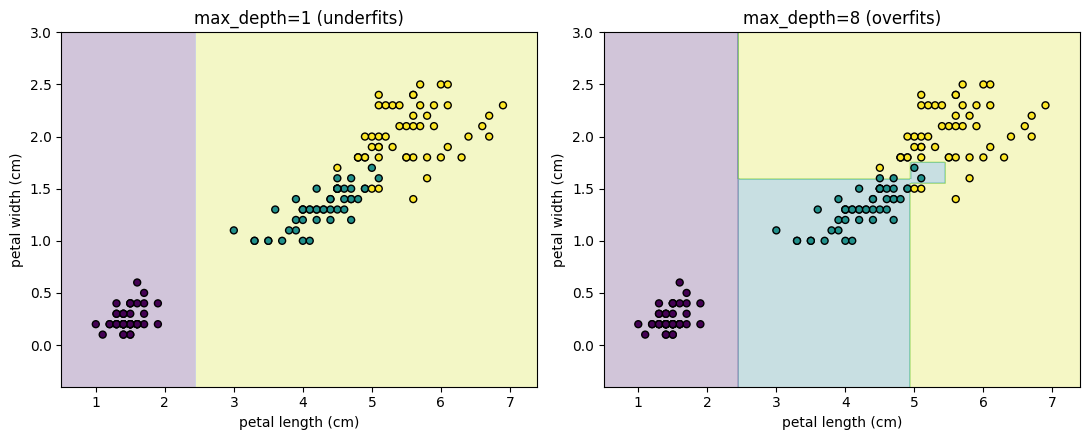

In [6]:
def plot_decision_boundary(X, y, model, ax, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="viridis")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", edgecolor="k", s=25)
    ax.set_title(title)
    ax.set_xlabel("petal length (cm)")
    ax.set_ylabel("petal width (cm)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
shallow = DecisionTreeClassifier(max_depth=1, random_state=42).fit(X_train, y_train)
deep = DecisionTreeClassifier(max_depth=8, random_state=42).fit(X_train, y_train)
plot_decision_boundary(X_iris, y_iris, shallow, axes[0], "max_depth=1 (underfits)")
plot_decision_boundary(X_iris, y_iris, deep, axes[1], "max_depth=8 (overfits)")
plt.tight_layout()
plt.show()

In [7]:
print(f"shallow (depth=1): train acc = {shallow.score(X_train, y_train):.3f}   test acc = {shallow.score(X_test, y_test):.3f}")
print(f"deep (depth=8):    train acc = {deep.score(X_train, y_train):.3f}   test acc = {deep.score(X_test, y_test):.3f}")

shallow (depth=1): train acc = 0.648   test acc = 0.711
deep (depth=8):    train acc = 0.990   test acc = 1.000


**What this particular run shows:** the deep tree actually wins on *both*
train and test accuracy here, rather than the textbook pattern of test accuracy dropping below
train. That's mostly the luck of this specific split and iris being an easy, cleanly-separated
dataset &mdash; the general risk (a deep tree overfitting noisier, messier data) is still real, it
just isn't what this exact comparison happens to demonstrate.

Notice the boundaries are always straight lines **parallel to an axis** &mdash; each split tests one
feature at a time. This is `max_depth=1` and `max_depth=8` from the general rule a few cells back,
made concrete: the shallow tree draws one line and calls it done (underfitting), while the deep tree
carves out tiny, contorted regions to fit individual training points exactly, including noise
(overfitting).

<span style="color:#b45309">**Exercise 1: Depth vs. accuracy**</span>

Fit `DecisionTreeClassifier` on the iris training data for `max_depth` values 1 through 8. For each,
record train accuracy and test accuracy, then plot both against depth. At what depth does test
accuracy stop improving (or start getting worse) even as train accuracy keeps climbing?

Try it in the cell below, then check the answer notebook (`Session 4b - Exercise Answers.ipynb`).

In [8]:
# your code here


## <span style="color:#1e3a8a">Why accuracy alone can mislead you</span>

Back to our own data. Let's build a classifier for something genuinely rare: a **big drop day**
for AAPL, defined as a daily return below $-3\%$.

In [9]:
aapl = df[df["Ticker Symbol"] == "AAPL"].copy()
aapl["BigDrop"] = (aapl["Returns"] < -0.03).astype(int)

print(f"share of big-drop days: {aapl['BigDrop'].mean():.3f}  ({aapl['BigDrop'].sum()} out of {len(aapl)})")

share of big-drop days: 0.057  (43 out of 756)


### Before fitting anything: the naive baseline

What would a classifier that does *zero* real work get, just by always guessing the majority class
("no drop")? That's the bar any real model has to clear &mdash; worth knowing *before* you see a
real model's accuracy, not after.

In [10]:
y = aapl["BigDrop"].values
naive_baseline_accuracy = 1 - y.mean()
print(f"a model that always predicts 'no drop': {naive_baseline_accuracy:.3f} accuracy")

a model that always predicts 'no drop': 0.943 accuracy


### Now fit a real model

Predict `BigDrop` from `MktReturn`, rescaled to percentage points from the start.

In [11]:
aapl["MktReturnPct"] = aapl["MktReturn"] * 100
X = aapl[["MktReturnPct"]].values

drop_model = LogisticRegression()
drop_model.fit(X, y)
pred = drop_model.predict(X)

print(f"model accuracy:  {drop_model.score(X, y):.3f}")
print(f"naive baseline:  {naive_baseline_accuracy:.3f}")

model accuracy:  0.962
naive baseline:  0.943


Only about 2 points better than doing nothing. **Does that mean the model barely works?** Before
answering from accuracy alone, look at what it's actually getting right and wrong &mdash; via the
**confusion matrix**, the 2&times;2 table of actual vs. predicted class:

| | Predicted: no drop | Predicted: big drop |
|---|---|---|
| **Actual: no drop** | True Negative (TN) | False Positive (FP) |
| **Actual: big drop** | False Negative (FN) | True Positive (TP) |

- **True Negative**: correctly predicted no drop.
- **False Positive**: a false alarm &mdash; predicted a drop that didn't happen.
- **False Negative**: missed a real drop.
- **True Positive**: correctly caught a real drop.


If this looks familiar: **False Positive is exactly a Type I error**, and **False Negative is
exactly a Type II error**, from Session 3's hypothesis-testing table. Same two ways to be wrong,
same trade-off between them &mdash; just relabeled for a classifier instead of a hypothesis test.

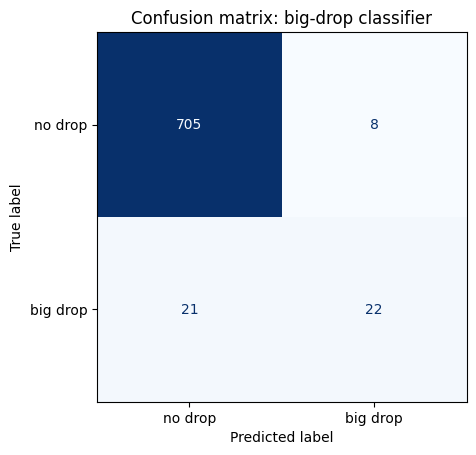

precision: 0.733
recall:    0.512
f1:        0.603


In [12]:
cm = confusion_matrix(y, pred)
ConfusionMatrixDisplay(cm, display_labels=["no drop", "big drop"]).plot(cmap="Blues", colorbar=False)
plt.title("Confusion matrix: big-drop classifier")
plt.show()

print(f"precision: {precision_score(y, pred, zero_division=0):.3f}")
print(f"recall:    {recall_score(y, pred, zero_division=0):.3f}")
print(f"f1:        {f1_score(y, pred, zero_division=0):.3f}")

Reading the four numbers in the plot (705, 8, 21, 22), same grid as above:
- **705** = True Negative &mdash; days with no big drop, correctly predicted "no drop"
- **8** = False Positive &mdash; false alarms (predicted "big drop," but it didn't happen)
- **21** = False Negative &mdash; missed drops (predicted "no drop," but a big drop happened)
- **22** = True Positive &mdash; actual big drops the model correctly caught

Check: 705+8+21+22 = 756 (every day accounted for). Precision = 22/(22+8) = 0.733. Recall =
22/(22+21) = 0.512 &mdash; matching the numbers printed just below the plot.

**Precision** = TP / (TP + FP) &mdash; of all the days we predicted "big drop," what share actually
were? Only the **"Predicted: big drop" column** is involved:

<table>
<tr><td></td><td>Predicted: no drop</td><td>Predicted: big drop</td></tr>
<tr><td>Actual: no drop</td><td>TN</td><td style="background-color:#fde68a;">FP</td></tr>
<tr><td>Actual: big drop</td><td>FN</td><td style="background-color:#fde68a;">TP</td></tr>
</table>

Here, 0.733: when this model raises an alarm, it's right about 73% of the time.

**Recall** = TP / (TP + FN) &mdash; of all the days that were *actually* a big drop, what share did
we catch? Only the **"Actual: big drop" row** is involved:

<table>
<tr><td></td><td>Predicted: no drop</td><td>Predicted: big drop</td></tr>
<tr><td>Actual: no drop</td><td>TN</td><td>FP</td></tr>
<tr><td>Actual: big drop</td><td style="background-color:#bfdbfe;">FN</td><td style="background-color:#bfdbfe;">TP</td></tr>
</table>

Here, 0.512: the model catches just over half of all real crashes.

**That's the real lesson.** Accuracy moved from 94.3% (naive) to 96.2% (this model) &mdash; a
~2-point improvement that on its own looks unremarkable. But recall moved from essentially 0% (the
naive model, by construction, never predicts a drop, so it never catches one) to 51.2% here. A small
accuracy gain hid a large, genuinely useful gain in the one thing this classifier is *for*: catching
real crashes. This is exactly why medical screening tests, fraud detectors, and churn models are
almost never evaluated on accuracy alone.

### The precision/recall trade-off

Even the rescaled model's default threshold (0.5) is just one choice among many. Let's look at the
predicted probabilities directly, and see what happens as we move the bar for calling something a
"big drop."

In [13]:
prob = drop_model.predict_proba(X)[:, 1]
print(f"predicted probability range: {prob.min():.4f} to {prob.max():.4f}")

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
results = []
for t in thresholds:
    pred_t = (prob >= t).astype(int)
    results.append({
        "threshold": t,
        "n_predicted_positive": pred_t.sum(),
        "precision": precision_score(y, pred_t, zero_division=0),
        "recall": recall_score(y, pred_t, zero_division=0),
        "f1": f1_score(y, pred_t, zero_division=0),
    })
pd.DataFrame(results).round(3)

predicted probability range: 0.0000 to 1.0000


,threshold,n_predicted_positive,precision,recall,f1
0,0.1,75,0.480,0.837,0.610
1,0.2,52,0.615,0.744,0.674
2,0.3,42,0.667,0.651,0.659
3,0.4,36,0.750,0.628,0.684
4,0.5,30,0.733,0.512,0.603
5,0.6,27,0.778,0.488,0.600
6,0.7,21,0.857,0.419,0.562
7,0.8,16,0.812,0.302,0.441


Now that the model is actually using the full 0&ndash;1 probability range (not squeezed into a
narrow band by a crushed coefficient), the threshold sweep looks like a textbook trade-off curve:
- A low threshold (0.1) catches most drops (recall 0.84) but with more false alarms (precision 0.48).
- Threshold 0.4 balances the two well: precision 0.75, recall 0.63, the best F1 in this sweep.
- A high threshold (0.8) is cautious: precision 0.81, but recall drops to 0.30 &mdash; it misses most
  actual drops.

**There is no single "correct" threshold** &mdash; it depends on the cost of a false alarm versus a
missed drop, which is a business decision, not a statistical one. A risk desk that wants to catch
every crash might accept many false alarms; a trading system that acts automatically on every alert
cannot.

**F1 score** is the harmonic mean of precision and recall, $2 \times \frac{P \times R}{P + R}$
&mdash; a single number for comparing thresholds (or models) without eyeballing two numbers at once.
Unlike a plain average, the harmonic mean punishes a big imbalance: a threshold with precision 1.0
but recall 0.02 (like an overly cautious model) gets a *low* F1, not a mediocre-looking 0.51,
because doing well on only one of the two doesn't count for much. It's a convenient summary &mdash;
but precision and recall are still the two numbers that tell you what kind of mistake the model
actually tends to make.

### When to prioritize which

The two errors (false positive vs. false negative) are almost never equally costly &mdash; which one
you should optimize for depends entirely on what happens after the model's decision:

- **Prioritize recall when missing a positive is the expensive mistake.** Medical screening for a
  serious disease, fraud detection, our own big-drop alert: a false negative here means a real crash,
  a real fraud, a real illness slips through undetected. You'd rather over-flag and double-check than
  miss the real thing.
- **Prioritize precision when a false alarm is the expensive mistake.** A spam filter that's too
  aggressive blocks real emails; an automated trading system that fires on every alert racks up
  transaction costs on false signals; a content-moderation system that's too trigger-happy flags
  innocent users. Here, a false positive actively annoys or costs someone, so you'd rather miss a few
  true positives than cry wolf constantly.

There's no universal answer &mdash; it's the same question as picking a threshold: what does *this*
specific mistake cost, in *this* specific use case?

<span style="color:#b45309">**Exercise 2: Pick your own threshold**</span>

Using `prob` and `y` from above, find the threshold (try a finer grid, e.g. `np.arange(0.01, 0.95, 0.01)`)
that maximizes recall while keeping precision at or above 0.5. Report the threshold, precision, and
recall you find, and explain in a sentence what kind of user (risk manager? trader?) might want that
exact trade-off.

Try it in the cell below, then check the answer notebook (`Session 4b - Exercise Answers.ipynb`).

In [14]:
# your code here


## <span style="color:#1e3a8a">For further study: calibration</span>

Precision and recall are about the 0/1 *decision*. A related, subtler question: when a model says
"12% chance of a big drop," does a big drop actually happen about 12% of the time in situations
like that? That's **calibration** &mdash; a model can rank observations correctly (riskier ones get
higher scores) while still being dishonest about the actual probability. It matters most when you
report a raw probability to a decision-maker (a risk score, a churn probability, a default
probability for pricing a loan), rather than just using the model to make a yes/no call.

Not covered hands-on today, but worth knowing the tools if you want to check it yourself later:
`sklearn.calibration.calibration_curve` (plots predicted probability against actual observed
frequency, bucket by bucket &mdash; a "reliability diagram") and `CalibratedClassifierCV` (refits a
correction curve on top of a model's raw scores). The `sklearn` calibration guide is a good starting
point if you want to explore this further.

## <span style="color:#1e3a8a">Looking ahead</span>

Two blocks, one lesson worth carrying forward: a model can look great on a summary statistic
(accuracy) and be useless at the one thing you built it for &mdash; and the fix is often as simple
(and as easy to skip) as checking your feature scales before trusting a suspiciously bad result.
That's exactly the kind of scrutiny "responsible and sound" analysis requires &mdash; the same
spirit as Session 3's causality checklist, now applied to prediction instead of explanation.

This afternoon: a different kind of model entirely &mdash; generative AI, and what it can and can't
actually do.